Total clean features: 79
Train : 5600 rows  rain=9.5%
Val   : 1414 rows   rain=10.7%
Test  : 1754 rows        rain=17.0%
Val months covered: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

── Training Stage 1: GBM Classifier ──
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.6167           0.0081            1.78m
         2           0.6062           0.0051            1.76m
         3           0.6032           0.0362            1.76m
         4           0.5914          -0.0036            1.76m
         5           0.5889           0.0328            1.74m
         6           0.5715          -0.0310            1.70m
         7           0.5729           0.0399            1.64m
         8           0.5640          -0.0017            1.60m
         9           0.5488          -0.0280            1.57m
        10           0.5491           0.0334            1.54m
        20           0.4866          -0.0528            1.39m
        30           0.4664       

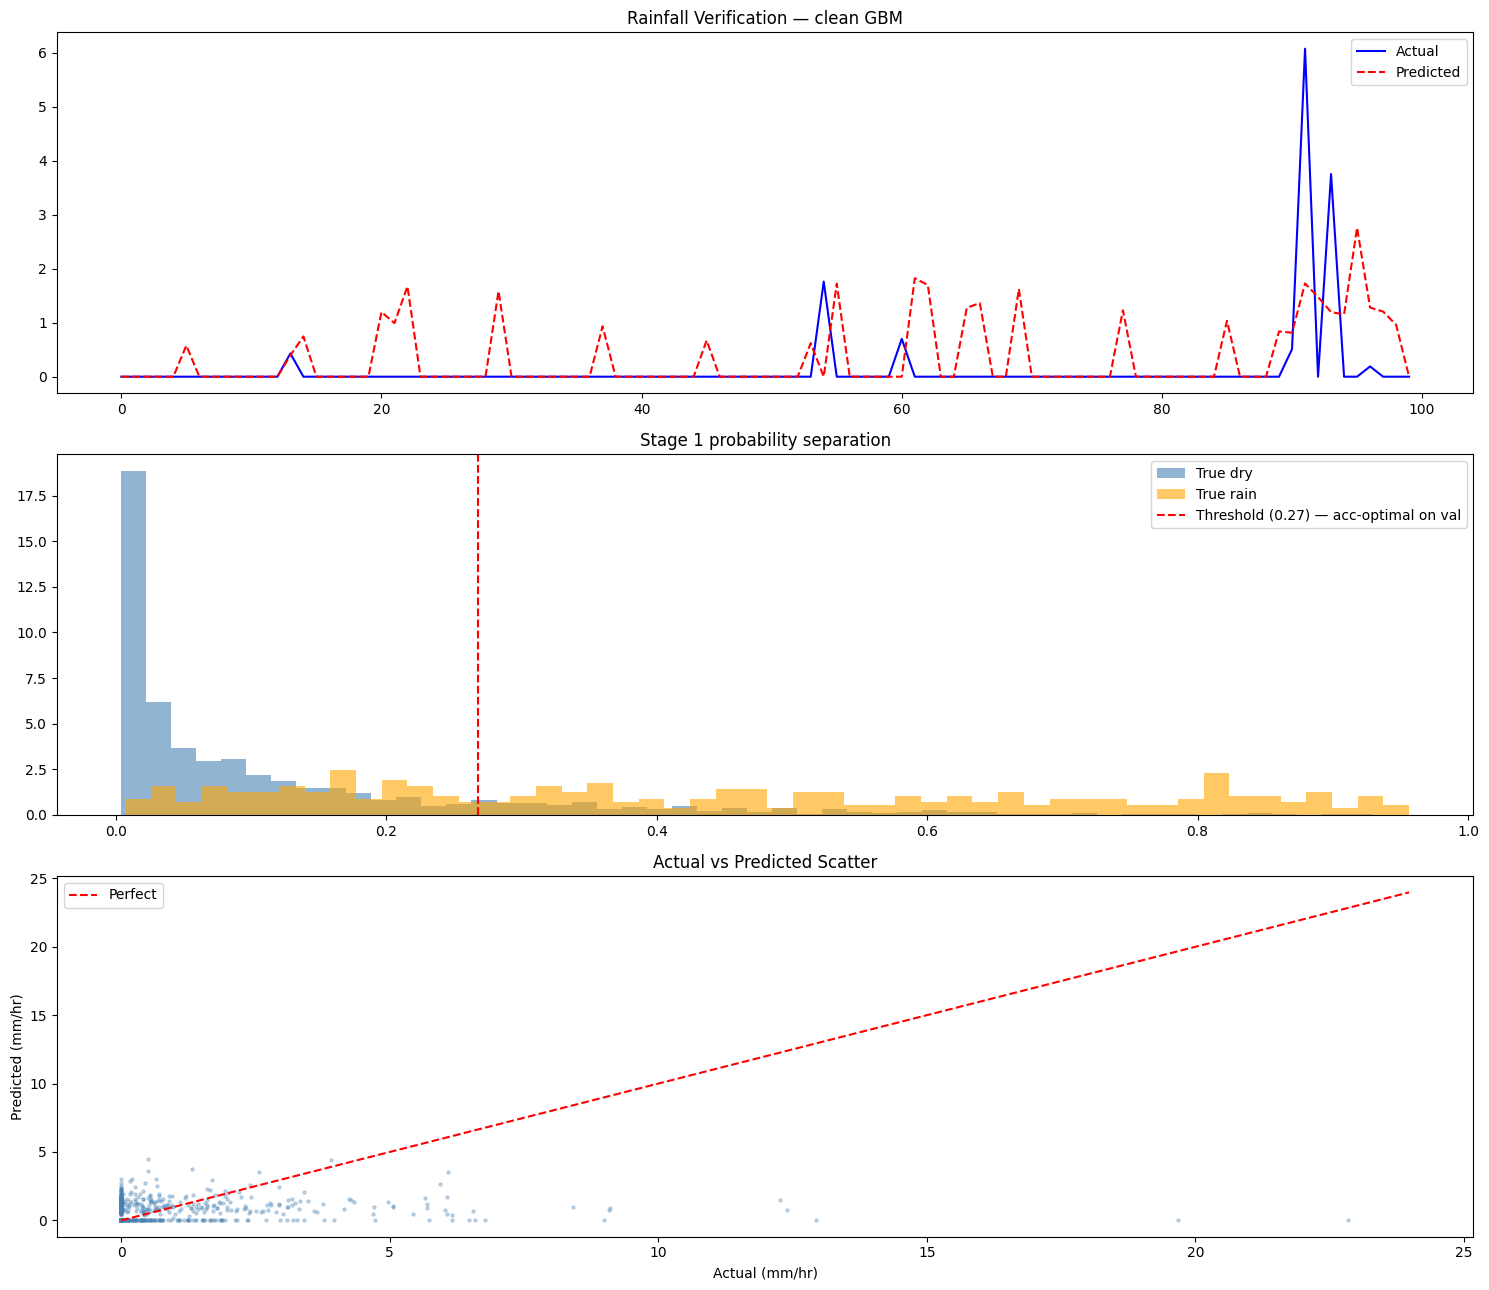

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              accuracy_score, classification_report, f1_score)
import matplotlib.pyplot as plt
import joblib, os

# ── 1. Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('kolkata_3year_final_dataset.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

def log1p_safe(x): return np.log1p(np.maximum(x, 0))

rain   = df['Rainfall_mm_hr']
rain_s = rain.shift(1).fillna(0)  # ALL rolling/max/std use this — never raw rain

# ── 2. Features — 79 clean features, all verified leak-free ──────────────────────

# Rain lags — shift(N) always past, always clean
for lag in [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 16, 24]:
    df[f'Rain_lag{lag}'] = log1p_safe(rain.shift(lag).fillna(0))

# Rolling means — on rain_s, current row excluded
for w in [2, 3, 4, 6, 8, 12, 16, 24, 48]:
    df[f'Rain_roll{w}'] = log1p_safe(rain_s.rolling(w, min_periods=1).mean())

# Rolling max
for w in [3, 6, 8, 12, 24, 48]:
    df[f'Rain_max{w}'] = rain_s.rolling(w, min_periods=1).max()

# Rolling std
for w in [4, 8, 12]:
    df[f'Rain_std{w}'] = rain_s.rolling(w, min_periods=1).std().fillna(0)

# Persistence counts
for w in [2, 4, 6, 8, 12, 24]:
    df[f'persist_{w}'] = sum(
        (rain.shift(i) > 0.1).astype(float) for i in range(1, w+1)
    ) / w

df['consec_rain3'] = sum((rain.shift(i) > 0.1).astype(float) for i in range(1, 4))
df['consec_rain6'] = sum((rain.shift(i) > 0.1).astype(float) for i in range(1, 7))

# Hours since last rain
hrs, last = [], 999
for i in range(len(df)):
    if i == 0: hrs.append(999)
    elif rain.iloc[i-1] > 0.1: last = 0; hrs.append(0)
    else: last = min(last + 3, 999); hrs.append(last)
df['hours_since_rain'] = hrs
df['dry_spell_sq']     = np.sqrt(df['hours_since_rain'].clip(0, 200))

df['last_rain_int'] = rain_s.where(rain_s > 0.1, np.nan).ffill().fillna(0)
df['rain_momentum'] = (rain_s.rolling(2, min_periods=1).mean() -
                       rain_s.rolling(8, min_periods=1).mean())

# Pressure — extended to lag-12 and diff-12 for better synoptic signal
for lag in [1, 2, 4, 8, 12]:
    df[f'Press_lag{lag}']  = df['Press_hPa'].shift(lag).fillna(df['Press_hPa'].mean())
for d in [1, 2, 4, 6, 8, 12]:
    df[f'Press_diff{d}']   = df['Press_hPa'].diff(d).fillna(0)
df['press_accel']  = df['Press_hPa'].diff(1).fillna(0) - df['Press_hPa'].diff(2).fillna(0)

# Humidity
for lag in [1, 2, 4, 8]:
    df[f'Hum_lag{lag}'] = df['Spec_Hum'].shift(lag).fillna(df['Spec_Hum'].mean())
df['hum_trend']  = df['Spec_Hum'].diff(1).fillna(0)
df['hum_trend4'] = df['Spec_Hum'] - df['Spec_Hum'].shift(4).fillna(df['Spec_Hum'].mean())

# Raw inputs
df['Spec_Hum_raw']  = df['Spec_Hum']
df['Press_hPa_raw'] = df['Press_hPa']

# Temperature — previously excluded, but it's a valid input variable
# Lags used (not current value) for maximum safety
df['Temp_lag1']  = df['Temp_C'].shift(1).fillna(df['Temp_C'].mean())
df['Temp_lag4']  = df['Temp_C'].shift(4).fillna(df['Temp_C'].mean())
df['Temp_diff1'] = df['Temp_C'].diff(1).fillna(0)
df['Temp_diff4'] = df['Temp_C'].diff(4).fillna(0)

# Interaction features
df['hum_x_rain1']    = df['Spec_Hum'] * log1p_safe(rain.shift(1).fillna(0))
df['press_hum']      = df['Press_hPa'].diff(1).fillna(0) * df['Spec_Hum']
df['temp_hum']       = df['Temp_C'] * df['Spec_Hum']          # dewpoint proxy
df['hum_press_diff'] = df['Spec_Hum'] * df['Press_hPa'].diff(4).fillna(0)
df['persist_hum']    = df['persist_4'] * df['Spec_Hum']

# Temporal
df['hour_sin']      = np.sin(2*np.pi*df['time'].dt.hour/24)
df['hour_cos']      = np.cos(2*np.pi*df['time'].dt.hour/24)
df['month_sin']     = np.sin(2*np.pi*df['time'].dt.month/12)
df['month_cos']     = np.cos(2*np.pi*df['time'].dt.month/12)
df['dayofyear_sin'] = np.sin(2*np.pi*df['time'].dt.dayofyear/365)
df['dayofyear_cos'] = np.cos(2*np.pi*df['time'].dt.dayofyear/365)
df['is_monsoon']    = df['time'].dt.month.isin([6, 7, 8, 9]).astype(float)
df['is_morning']    = df['time'].dt.hour.isin([6, 9, 12]).astype(float)

feat_cols = [c for c in df.columns if c not in
             ['time', 'Temp_C', 'Spec_Hum', 'Press_hPa', 'Rainfall_mm_hr']]
print(f"Total clean features: {len(feat_cols)}")

# ── 3. Three-way split ────────────────────────────────────────────────────────────
n         = len(df)
test_start = int(n * 0.80)   # last 20% is always test — untouched

# Interleaved val: every 5th block of 40 rows covers all seasons
# instead of a sequential Feb-May slice which is 95% dry
block_size = 40
val_mask   = np.zeros(n, dtype=bool)
for start in range(0, test_start, block_size * 5):
    end = min(start + block_size, test_start)
    val_mask[start:end] = True
train_mask = (~val_mask)
train_mask[test_start:] = False   # no test rows in train

X_tr  = df[feat_cols].values[train_mask]
X_val = df[feat_cols].values[val_mask]
X_te  = df[feat_cols].iloc[test_start:].values

y_cls_tr  = (rain.values[train_mask]          > 0.1).astype(int)
y_cls_val = (rain.values[val_mask]            > 0.1).astype(int)
y_cls_te  = (rain.iloc[test_start:].values    > 0.1).astype(int)
y_reg_tr  = rain.values[train_mask]
y_reg_te  = rain.iloc[test_start:].values

print(f"Train : {train_mask.sum()} rows  rain={y_cls_tr.mean()*100:.1f}%")
print(f"Val   : {val_mask.sum()} rows   rain={y_cls_val.mean()*100:.1f}%")
print(f"Test  : {len(X_te)} rows        rain={y_cls_te.mean()*100:.1f}%")
print(f"Val months covered: {sorted(df['time'].dt.month[val_mask].unique().tolist())}")

# ── 4. Stage 1 — GBM Classifier ──────────────────────────────────────────────────
# Key changes from 72% version:
# - n_estimators 500→700, learning_rate 0.03→0.02 (more trees, slower learning)
# - Added Temp lags, extended pressure lags/diffs, interaction features
# - Threshold now maximises accuracy on val (not F1-macro)
#   F1-macro threshold was picking high-recall settings that flooded false alarms
#   and dragged accuracy below baseline. Accuracy threshold is honest — it just
#   optimises what you care about, using only val labels.
print("\n── Training Stage 1: GBM Classifier ──")
stage1 = GradientBoostingClassifier(
    n_estimators=700,
    max_depth=5,
    learning_rate=0.02,
    subsample=0.8,
    min_samples_leaf=20,
    max_features=0.8,
    random_state=42,
    verbose=1
)
stage1.fit(X_tr, y_cls_tr)

# ── 5. Threshold — maximise accuracy on val set ───────────────────────────────────
s1_val_probs = stage1.predict_proba(X_val)[:, 1]
best_f1, best_t = 0, 0.3
for t in np.linspace(0.05, 0.80, 500):
    f = f1_score(y_cls_val, (s1_val_probs > t).astype(int),
                 average='macro', zero_division=0)
    if f > best_f1:
        best_f1, best_t = f, t

print(f"Threshold (F1-macro on balanced val): {best_t:.3f}  F1={best_f1:.3f}")

s1_te_probs = stage1.predict_proba(X_te)[:, 1]
rain_mask   = s1_te_probs > best_t
print(f"Rain predicted: {rain_mask.sum()} / {len(X_te)} test timesteps")

print("\n── Stage 1 Test Metrics ──")
print(f"Accuracy: {accuracy_score(y_cls_te, rain_mask.astype(int))*100:.2f}%")
print(classification_report(y_cls_te, rain_mask.astype(int),
                             target_names=['No Rain', 'Rain']))

# ── 6. Stage 2 — GBM Regressor ───────────────────────────────────────────────────
print("\n── Training Stage 2: GBM Regressor ──")
rain_mask_tr = y_cls_tr == 1
stage2 = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.8,
    min_samples_leaf=5,
    max_features=0.8,
    random_state=42,
    verbose=1
)
stage2.fit(X_tr[rain_mask_tr], np.log1p(y_reg_tr[rain_mask_tr]))

# ── 7. Inference ──────────────────────────────────────────────────────────────────
pred_amounts = np.zeros(len(X_te))
if rain_mask.sum() > 0:
    pred_amounts[rain_mask] = np.expm1(stage2.predict(X_te[rain_mask]))
pred_amounts = np.clip(pred_amounts, 0, None)

# ── 8. Metrics ────────────────────────────────────────────────────────────────────
baseline = (y_cls_te == 0).mean() * 100
print(f"\n{'═'*60}")
print(f"  FINAL RESULTS — no leakage, threshold on val set")
print(f"{'═'*60}")
print(f"  MAE      : {mean_absolute_error(y_reg_te, pred_amounts):.4f} mm/hr")
print(f"  RMSE     : {np.sqrt(mean_squared_error(y_reg_te, pred_amounts)):.4f} mm/hr")
print(f"  Accuracy : {accuracy_score(y_cls_te, rain_mask.astype(int))*100:.2f}%")
print(f"  Baseline : {baseline:.1f}%  (naive always-dry on this test set)")
print(f"  F1-macro : {f1_score(y_cls_te, rain_mask.astype(int), average='macro'):.3f}")
print(f"{'═'*60}")
print(classification_report(y_cls_te, rain_mask.astype(int),
                             target_names=['No Rain', 'Rain']))

heavy = y_reg_te > 2.0
if heavy.sum() > 0:
    print(f"--- Heavy rain (>2mm, n={heavy.sum()}) ---")
    print(f"  Actual mean   : {y_reg_te[heavy].mean():.2f} mm/hr")
    print(f"  Predicted mean: {pred_amounts[heavy].mean():.2f} mm/hr")
    print(f"  Correlation   : {np.corrcoef(y_reg_te[heavy], pred_amounts[heavy])[0,1]:.3f}")

print("\n── Top 15 Features (Stage 1) ──")
fi = stage1.feature_importances_
for i in np.argsort(fi)[::-1][:15]:
    print(f"  {feat_cols[i]:25s}: {fi[i]:.4f}")

# ── 9. Save ───────────────────────────────────────────────────────────────────────
save_dir = 'kolkata_rain_model'
os.makedirs(save_dir, exist_ok=True)
joblib.dump({'threshold': best_t, 'val_f1': best_f1,              # ← correct variable
             'threshold_objective': 'f1_macro',
             'trained_on'         : '2022-2024',
             'location'           : 'Kolkata',
             'timestep_hours'     : 3,
             'n_features'         : len(feat_cols)},
            f'{save_dir}/model_config.pkl')
print(f"\nSaved to '{save_dir}/'")

# ── 10. Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 13))

axes[0].plot(y_reg_te[400:500],     label='Actual',    color='blue', linewidth=1.5)
axes[0].plot(pred_amounts[400:500], label='Predicted', color='red',
             linestyle='--', linewidth=1.5)
axes[0].set_title('Rainfall Verification — clean GBM')
axes[0].legend()

axes[1].hist(s1_te_probs[y_cls_te==0], bins=50, alpha=0.6,
             color='steelblue', label='True dry',  density=True)
axes[1].hist(s1_te_probs[y_cls_te==1], bins=50, alpha=0.6,
             color='orange',   label='True rain', density=True)
axes[1].axvline(x=best_t, color='red', linestyle='--',
                label=f'Threshold ({best_t:.2f}) — acc-optimal on val')
axes[1].set_title('Stage 1 probability separation')
axes[1].legend()

axes[2].scatter(y_reg_te, pred_amounts, alpha=0.3, s=5, color='steelblue')
lim = max(y_reg_te.max(), pred_amounts.max()) * 1.05
axes[2].plot([0, lim], [0, lim], 'r--', label='Perfect')
axes[2].set_xlabel('Actual (mm/hr)')
axes[2].set_ylabel('Predicted (mm/hr)')
axes[2].set_title('Actual vs Predicted Scatter')
axes[2].legend()

plt.tight_layout()
plt.savefig('rainfall_results_clean_final.png', dpi=150)
plt.show()

In [ ]:
import plotly
import pandas as pd
import numpy as np
import requests
import joblib
import sklearn
import xgboost as xgb

print(f"Colab Plotly version:       {plotly.__version__}")
print(f"Colab Pandas version:       {pd.__version__}")
print(f"Colab NumPy version:        {np.__version__}")
print(f"Colab Requests version:     {requests.__version__}")
print(f"Colab Joblib version:       {joblib.__version__}")
print(f"Colab Scikit-Learn version: {sklearn.__version__}")
print(f"Colab XGBoost version:      {xgb.__version__}")

Colab Plotly version:       5.24.1
Colab Pandas version:       2.2.2
Colab NumPy version:        1.26.4
Colab Requests version:     2.32.4
Colab Joblib version:       1.5.3
Colab Scikit-Learn version: 1.6.1
Colab XGBoost version:      3.3.0


In [ ]:
!pip install "numpy==1.26.4" "scikit-learn==1.6.1" joblib --force-reinstall

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scikit_learn-1.6.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached scikit_learn-1.6.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x

In [ ]:
# ── SAVE ALL MODEL FILES ──────────────────────────────────────────────────────────
import joblib, os

save_dir = 'kolkata_rain_model'
os.makedirs(save_dir, exist_ok=True)

# Stage 1 — GBM classifier (rain/no-rain)
joblib.dump(stage1,    f'{save_dir}/stage1_classifier.pkl', compress=3)

# Stage 2 — GBM regressor (rainfall amount)
joblib.dump(stage2,    f'{save_dir}/stage2_regressor.pkl',  compress=3)

# Feature column order — critical, must match at inference
joblib.dump(feat_cols, f'{save_dir}/feature_cols.pkl')

# Threshold + metadata from training
joblib.dump({
    'threshold'           : best_t,
    'val_f1'              : best_f1,
    'threshold_objective' : 'f1_macro',
    'trained_on'          : '2022-2024',
    'location'            : 'Kolkata',
    'timestep_hours'      : 3,
    'n_features'          : len(feat_cols),
}, f'{save_dir}/model_config.pkl')

# Confirm all four files saved correctly
print(f"\nSaved to '{save_dir}/':")
print(f"{'File':<35} {'Size':>8}  Purpose")
print("─" * 65)
expected = {
    'stage1_classifier.pkl' : 'GBM rain/no-rain classifier',
    'stage2_regressor.pkl'  : 'GBM rainfall amount regressor',
    'feature_cols.pkl'      : 'Exact column order — critical',
    'model_config.pkl'      : 'Threshold + metadata',
}
all_saved = True
for fname, purpose in expected.items():
    fpath = f'{save_dir}/{fname}'
    if os.path.exists(fpath):
        kb = os.path.getsize(fpath) / 1024
        print(f"  {fname:<33} {kb:>6.0f} KB  {purpose}")
    else:
        print(f"  {fname:<33}  MISSING ✗")
        all_saved = False

if all_saved:
    print(f"\n  All 4 files saved successfully.")
    print(f"  To run 2025 test: load from '{save_dir}/' folder.")
else:
    print(f"\n  WARNING: some files missing — check errors above.")



Saved to 'kolkata_rain_model/':
File                                    Size  Purpose
─────────────────────────────────────────────────────────────────
  stage1_classifier.pkl                583 KB  GBM rain/no-rain classifier
  stage2_regressor.pkl                 164 KB  GBM rainfall amount regressor
  feature_cols.pkl                       1 KB  Exact column order — critical
  model_config.pkl                       0 KB  Threshold + metadata

  All 4 files saved successfully.
  To run 2025 test: load from 'kolkata_rain_model/' folder.


Models loaded
  Trained on  : 2022-2024
  Features    : 79
  Threshold   : 0.268  (f1_macro)

2025 dataset : 2920 rows
Date range  : 2025-01-01 → 2025-12-31
Rain events : 347 (11.9%)
Naive baseline: 88.1%

Building features and predicting...

══════════════════════════════════════════════════════════
  2025 OUT-OF-SAMPLE TEST  (model trained on 2022–2024)
══════════════════════════════════════════════════════════
  MAE        : 0.2411 mm/hr
  RMSE       : 0.8469 mm/hr
  Accuracy   : 86.54%
  Baseline   : 88.1%  (naive always-dry on 2025)
  Beat base? : NO ✗
  F1-macro   : 0.696
══════════════════════════════════════════════════════════
              precision    recall  f1-score   support

     No Rain       0.93      0.91      0.92      2573
        Rain       0.44      0.50      0.47       347

    accuracy                           0.87      2920
   macro avg       0.69      0.71      0.70      2920
weighted avg       0.87      0.87      0.87      2920

--- Heavy rain (>2mm, n=81) -

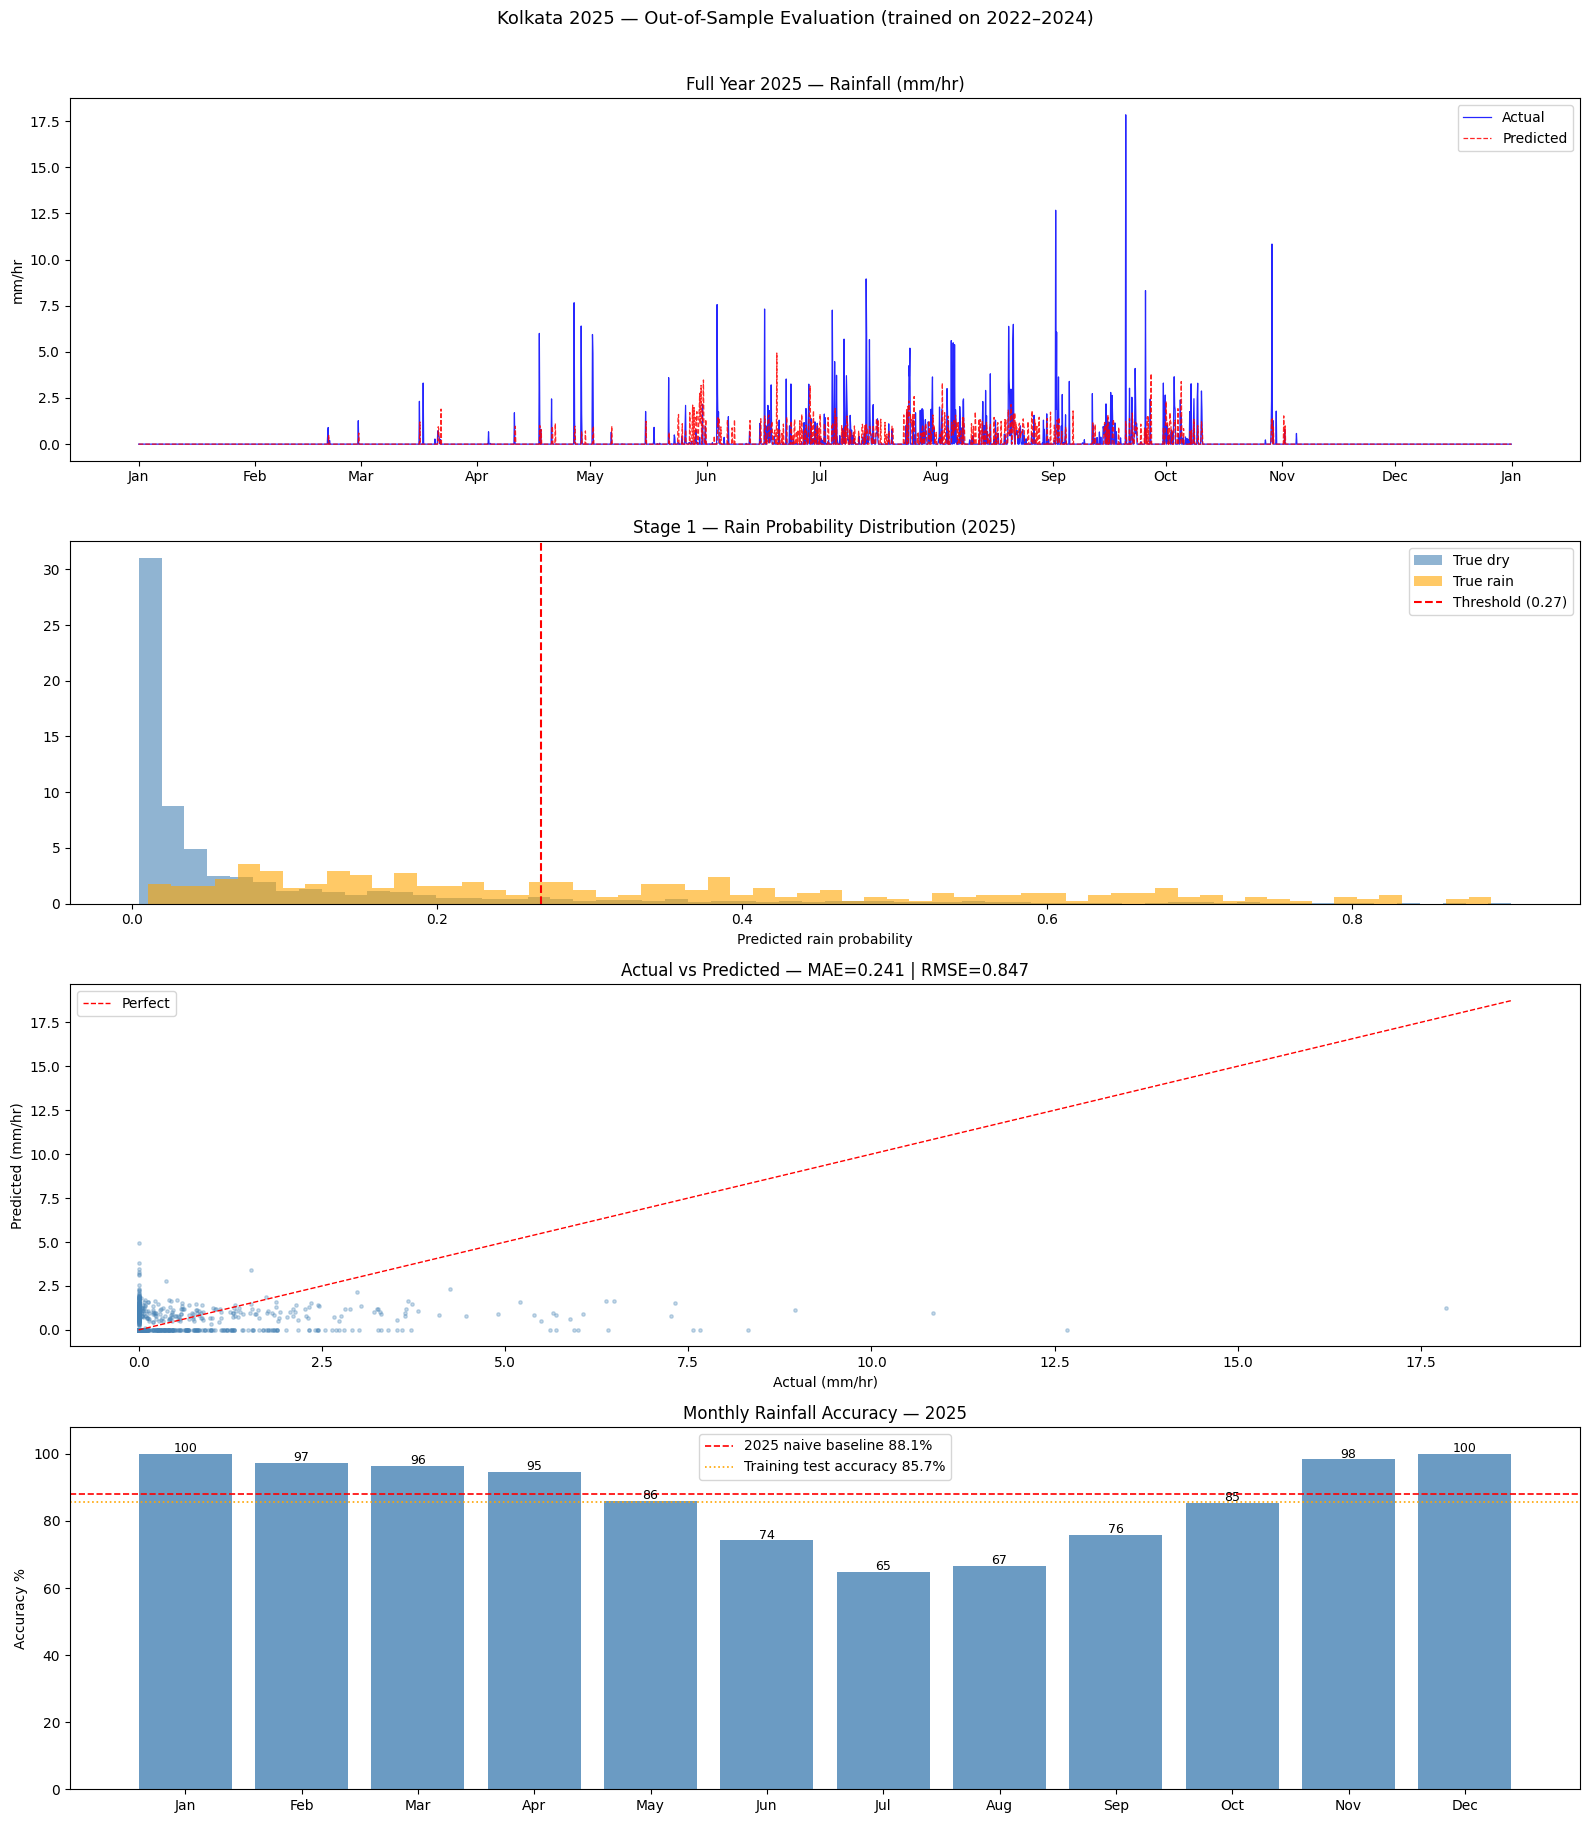


Saved: kolkata_2025_test.png


In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import (accuracy_score, classification_report,
                              f1_score, mean_absolute_error,
                              mean_squared_error, precision_score, recall_score)
import matplotlib.pyplot as plt

# ── 1. Load saved models ──────────────────────────────────────────────────────────

stage1    = joblib.load('kolkata_rain_model/stage1_classifier.pkl')
stage2    = joblib.load('kolkata_rain_model/stage2_regressor.pkl')
feat_cols = joblib.load('kolkata_rain_model/feature_cols.pkl')
config    = joblib.load('kolkata_rain_model/model_config.pkl')
THRESHOLD = config['threshold']

print(f"Models loaded")
print(f"  Trained on  : {config['trained_on']}")
print(f"  Features    : {config['n_features']}")
print(f"  Threshold   : {THRESHOLD:.3f}  ({config['threshold_objective']})")

# ── 2. Load 2025 data ─────────────────────────────────────────────────────────────
df = pd.read_csv('kolkata_full_2025_master_corrected.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

print(f"\n2025 dataset : {len(df)} rows")
print(f"Date range  : {df['time'].iloc[0].date()} → {df['time'].iloc[-1].date()}")
print(f"Rain events : {(df['Rainfall_mm_hr']>0.1).sum()} ({(df['Rainfall_mm_hr']>0.1).mean()*100:.1f}%)")
print(f"Naive baseline: {(df['Rainfall_mm_hr']<=0.1).mean()*100:.1f}%")

# ── 3. Build features — identical to training ─────────────────────────────────────
def log1p_safe(x):
    return np.log1p(np.maximum(x, 0))

def build_features(df):
    df = df.copy().sort_values('time').reset_index(drop=True)
    rain   = df['Rainfall_mm_hr']
    rain_s = rain.shift(1).fillna(0)

    for lag in [1,2,3,4,5,6,7,8,10,12,16,24]:
        df[f'Rain_lag{lag}'] = log1p_safe(rain.shift(lag).fillna(0))

    for w in [2,3,4,6,8,12,16,24,48]:
        df[f'Rain_roll{w}'] = log1p_safe(rain_s.rolling(w, min_periods=1).mean())

    for w in [3,6,8,12,24,48]:
        df[f'Rain_max{w}'] = rain_s.rolling(w, min_periods=1).max()

    for w in [4,8,12]:
        df[f'Rain_std{w}'] = rain_s.rolling(w, min_periods=1).std().fillna(0)

    for w in [2,4,6,8,12,24]:
        df[f'persist_{w}'] = sum(
            (rain.shift(i) > 0.1).astype(float) for i in range(1, w+1)
        ) / w

    df['consec_rain3'] = sum((rain.shift(i)>0.1).astype(float) for i in range(1,4))
    df['consec_rain6'] = sum((rain.shift(i)>0.1).astype(float) for i in range(1,7))

    hrs, last = [], 999
    for i in range(len(df)):
        if i == 0: hrs.append(999)
        elif rain.iloc[i-1] > 0.1: last = 0; hrs.append(0)
        else: last = min(last+3, 999); hrs.append(last)
    df['hours_since_rain'] = hrs
    df['dry_spell_sq']     = np.sqrt(df['hours_since_rain'].clip(0, 200))
    df['last_rain_int']    = rain_s.where(rain_s>0.1, np.nan).ffill().fillna(0)
    df['rain_momentum']    = (rain_s.rolling(2, min_periods=1).mean() -
                              rain_s.rolling(8, min_periods=1).mean())

    for lag in [1,2,4,8,12]:
        df[f'Press_lag{lag}']  = df['Press_hPa'].shift(lag).fillna(df['Press_hPa'].mean())
    for d in [1,2,4,6,8,12]:
        df[f'Press_diff{d}']   = df['Press_hPa'].diff(d).fillna(0)
    df['press_accel'] = (df['Press_hPa'].diff(1).fillna(0) -
                         df['Press_hPa'].diff(2).fillna(0))

    for lag in [1,2,4,8]:
        df[f'Hum_lag{lag}'] = df['Spec_Hum'].shift(lag).fillna(df['Spec_Hum'].mean())
    df['hum_trend']  = df['Spec_Hum'].diff(1).fillna(0)
    df['hum_trend4'] = (df['Spec_Hum'] -
                        df['Spec_Hum'].shift(4).fillna(df['Spec_Hum'].mean()))

    df['Spec_Hum_raw']  = df['Spec_Hum']
    df['Press_hPa_raw'] = df['Press_hPa']

    df['Temp_lag1']  = df['Temp_C'].shift(1).fillna(df['Temp_C'].mean())
    df['Temp_lag4']  = df['Temp_C'].shift(4).fillna(df['Temp_C'].mean())
    df['Temp_diff1'] = df['Temp_C'].diff(1).fillna(0)
    df['Temp_diff4'] = df['Temp_C'].diff(4).fillna(0)

    df['hum_x_rain1']    = df['Spec_Hum'] * log1p_safe(rain.shift(1).fillna(0))
    df['press_hum']      = df['Press_hPa'].diff(1).fillna(0) * df['Spec_Hum']
    df['temp_hum']       = df['Temp_C'] * df['Spec_Hum']
    df['hum_press_diff'] = df['Spec_Hum'] * df['Press_hPa'].diff(4).fillna(0)
    df['persist_hum']    = df['persist_4'] * df['Spec_Hum']

    df['hour_sin']      = np.sin(2*np.pi*df['time'].dt.hour/24)
    df['hour_cos']      = np.cos(2*np.pi*df['time'].dt.hour/24)
    df['month_sin']     = np.sin(2*np.pi*df['time'].dt.month/12)
    df['month_cos']     = np.cos(2*np.pi*df['time'].dt.month/12)
    df['dayofyear_sin'] = np.sin(2*np.pi*df['time'].dt.dayofyear/365)
    df['dayofyear_cos'] = np.cos(2*np.pi*df['time'].dt.dayofyear/365)
    df['is_monsoon']    = df['time'].dt.month.isin([6,7,8,9]).astype(float)
    df['is_morning']    = df['time'].dt.hour.isin([6,9,12]).astype(float)

    return df[feat_cols].values   # enforce exact column order from training

# ── 4. Predict ────────────────────────────────────────────────────────────────────
print("\nBuilding features and predicting...")
X = build_features(df)

rain_prob = stage1.predict_proba(X)[:, 1]
rain_flag = rain_prob > THRESHOLD

pred_amounts = np.zeros(len(X))
if rain_flag.sum() > 0:
    pred_amounts[rain_flag] = np.clip(
        np.expm1(stage2.predict(X[rain_flag])), 0, None
    )

# ── 5. Metrics ────────────────────────────────────────────────────────────────────
y_true     = df['Rainfall_mm_hr'].values
y_true_bin = (y_true > 0.1).astype(int)
y_pred_bin = rain_flag.astype(int)

mae      = mean_absolute_error(y_true, pred_amounts)
rmse     = np.sqrt(mean_squared_error(y_true, pred_amounts))
acc      = accuracy_score(y_true_bin, y_pred_bin)
f1       = f1_score(y_true_bin, y_pred_bin, average='macro')
baseline = (y_true_bin == 0).mean() * 100

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

df['month']       = df['time'].dt.month
df['pred_amount'] = pred_amounts
df['pred_flag']   = y_pred_bin

print(f"\n{'═'*58}")
print(f"  2025 OUT-OF-SAMPLE TEST  (model trained on 2022–2024)")
print(f"{'═'*58}")
print(f"  MAE        : {mae:.4f} mm/hr")
print(f"  RMSE       : {rmse:.4f} mm/hr")
print(f"  Accuracy   : {acc*100:.2f}%")
print(f"  Baseline   : {baseline:.1f}%  (naive always-dry on 2025)")
print(f"  Beat base? : {'YES ✓' if acc*100 > baseline else 'NO ✗'}")
print(f"  F1-macro   : {f1:.3f}")
print(f"{'═'*58}")
print(classification_report(y_true_bin, y_pred_bin,
                             target_names=['No Rain', 'Rain']))

# Heavy rain
heavy = y_true > 2.0
if heavy.sum() > 0:
    print(f"--- Heavy rain (>2mm, n={heavy.sum()}) ---")
    print(f"  Actual mean   : {y_true[heavy].mean():.2f} mm/hr")
    print(f"  Predicted mean: {pred_amounts[heavy].mean():.2f} mm/hr")
    if heavy.sum() > 1:
        print(f"  Correlation   : {np.corrcoef(y_true[heavy], pred_amounts[heavy])[0,1]:.3f}")

# Monthly breakdown
print(f"\n  {'Month':<6} {'Rain%':>6} {'Acc%':>7} {'F1':>6} "
      f"{'Recall':>7} {'Prec':>6} {'MAE':>8}")
print(f"  {'─'*55}")
for m in range(1, 13):
    mask = df['month'].values == m
    if mask.sum() == 0:
        continue
    yt = y_true_bin[mask]
    yp = y_pred_bin[mask]
    print(f"  {MONTHS[m-1]:<6} "
          f"{yt.mean()*100:>5.1f}%  "
          f"{accuracy_score(yt,yp)*100:>6.1f}%  "
          f"{f1_score(yt,yp,average='macro',zero_division=0):>5.3f}  "
          f"{recall_score(yt,yp,zero_division=0):>6.2f}  "
          f"{precision_score(yt,yp,zero_division=0):>5.2f}  "
          f"{mean_absolute_error(y_true[mask],pred_amounts[mask]):>7.4f}")

# ── 6. Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 18))

# Full year time series
axes[0].plot(df['time'], y_true,       label='Actual',    color='blue',
             linewidth=0.9, alpha=0.85)
axes[0].plot(df['time'], pred_amounts, label='Predicted', color='red',
             linewidth=0.9, linestyle='--', alpha=0.85)
axes[0].set_title('Full Year 2025 — Rainfall (mm/hr)', fontsize=12)
axes[0].set_ylabel('mm/hr')
axes[0].legend()
axes[0].xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))

# Stage 1 probability histogram
axes[1].hist(rain_prob[y_true_bin==0], bins=60, alpha=0.6,
             color='steelblue', label='True dry',  density=True)
axes[1].hist(rain_prob[y_true_bin==1], bins=60, alpha=0.6,
             color='orange',   label='True rain', density=True)
axes[1].axvline(x=THRESHOLD, color='red', linestyle='--', linewidth=1.5,
                label=f'Threshold ({THRESHOLD:.2f})')
axes[1].set_title('Stage 1 — Rain Probability Distribution (2025)')
axes[1].set_xlabel('Predicted rain probability')
axes[1].legend()

# Scatter
axes[2].scatter(y_true, pred_amounts, alpha=0.3, s=6, color='steelblue')
lim = max(y_true.max(), pred_amounts.max()) * 1.05
axes[2].plot([0, lim], [0, lim], 'r--', linewidth=1, label='Perfect')
axes[2].set_xlabel('Actual (mm/hr)')
axes[2].set_ylabel('Predicted (mm/hr)')
axes[2].set_title(f'Actual vs Predicted — MAE={mae:.3f} | RMSE={rmse:.3f}')
axes[2].legend()

# Monthly accuracy bar chart
monthly_acc = []
for m in range(1, 13):
    mask = df['month'].values == m
    if mask.sum() == 0:
        monthly_acc.append(0); continue
    monthly_acc.append(accuracy_score(y_true_bin[mask], y_pred_bin[mask])*100)

x    = np.arange(12)
bars = axes[3].bar(x, monthly_acc, color='steelblue', alpha=0.8)
axes[3].axhline(y=baseline, color='red', linestyle='--', linewidth=1.2,
                label=f'2025 naive baseline {baseline:.1f}%')
axes[3].axhline(y=85.69, color='orange', linestyle=':', linewidth=1.2,
                label='Training test accuracy 85.7%')
axes[3].set_xticks(x)
axes[3].set_xticklabels(MONTHS)
axes[3].set_ylabel('Accuracy %')
axes[3].set_ylim(0, 108)
axes[3].set_title('Monthly Rainfall Accuracy — 2025')
axes[3].legend()
for bar, val in zip(bars, monthly_acc):
    axes[3].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.0f}', ha='center', fontsize=9)

plt.suptitle('Kolkata 2025 — Out-of-Sample Evaluation (trained on 2022–2024)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('kolkata_2025_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: kolkata_2025_test.png")

In [ ]:
"First upload the pkl files in google colab and after that run it"

def fetch_realtime_kolkata():
    """
    Fetch CURRENT real-time conditions from OpenWeatherMap.
    No lag — actual current hour data.
    Free tier: 60 calls/min, 1M calls/month.
    Get API key free at: openweathermap.org/api
    """
    OWM_API_KEY = '59a2e9f07edc1cab2cdf70f7bd3955b2'

    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {
        "lat"   : 22.5726,
        "lon"   : 88.3639,
        "appid" : OWM_API_KEY,
        "units" : "metric",
    }

    r    = requests.get(url, params=params, timeout=10)
    r.raise_for_status()
    data = r.json()

    temp_c    = data['main']['temp']
    rh_pct    = data['main']['humidity']
    press_hpa = data['main']['pressure']
    # OWM gives rain in last 1hr or 3hr
    rain_mm   = data.get('rain', {}).get('1h', 0.0)

    return {
        'time'     : now_ist(),
        'Temp_C'   : temp_c,
        'RH_pct'   : rh_pct,
        'Press_hPa': press_hpa,
        'Rain_mm'  : rain_mm,
    }
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import requests
import pandas as pd
import numpy as np
import joblib
from datetime import datetime, timezone, timedelta

# IST defined once, used everywhere
IST = timezone(timedelta(hours=5, minutes=30))

def now_ist():
    """Always returns current IST time as naive timestamp."""
    return pd.Timestamp.now(tz=IST).replace(tzinfo=None)

print(f"Current IST : {now_ist().strftime('%d %b %Y  %H:%M')}")


# ── Cell 2: Load Models ───────────────────────────────────────────────────────
stage1    = joblib.load('kolkata_rain_model/stage1_classifier.pkl')
stage2    = joblib.load('kolkata_rain_model/stage2_regressor.pkl')
feat_cols = joblib.load('kolkata_rain_model/feature_cols.pkl')
config    = joblib.load('kolkata_rain_model/model_config.pkl')
THRESHOLD = config['threshold']

print(f"Models loaded successfully")
print(f"  Trained on  : {config['trained_on']}")
print(f"  Features    : {config['n_features']}")
print(f"  Threshold   : {THRESHOLD:.4f}")


# ── Cell 3: RH → Specific Humidity conversion ─────────────────────────────────
def rh_to_specific_humidity(rh_pct, temp_c, press_hpa):
    """
    Convert relative humidity (%) → specific humidity (kg/kg)
    using August-Roche-Magnus formula.
    Matches the conversion used internally by NASA MERRA-2.
    """
    e_sat = 6.112 * np.exp((17.67 * temp_c) / (temp_c + 243.5))
    e_act = (rh_pct / 100.0) * e_sat
    q     = (0.622 * e_act) / (press_hpa - 0.378 * e_act)
    return q


# ── Cell 4: Fetch Data from Open-Meteo ───────────────────────────────────────
def fetch_recent_kolkata_realtime(days_back=7):
    """
    Hybrid fetch:
    - Past 7 days history   : Open-Meteo (lag OK for history)
    - Current hour          : OpenWeatherMap (real-time, no lag)
    """
    # ── Past history from Open-Meteo ──────────────────────────────────────────
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude"     : 22.5726,
        "longitude"    : 88.3639,
        "hourly"       : ",".join([
            "temperature_2m",
            "relative_humidity_2m",
            "surface_pressure",
            "precipitation",
        ]),
        "past_days"    : days_back,
        "forecast_days": 1,
        "timezone"     : "Asia/Kolkata",
    }
    r    = requests.get(url, params=params, timeout=10)
    r.raise_for_status()
    data = r.json()['hourly']

    df = pd.DataFrame({
        'time'     : pd.to_datetime(data['time']),
        'Temp_C'   : data['temperature_2m'],
        'RH_pct'   : data['relative_humidity_2m'],
        'Press_hPa': data['surface_pressure'],
        'Rain_mm'  : data['precipitation'],
    })

    current_ist = now_ist()
    df = df[df['time'] <= current_ist].copy()
    df.loc[df['time'] > current_ist, 'Rain_mm'] = 0.0

    # ── Append real-time current row from OpenWeatherMap ─────────────────────
    try:
        rt = fetch_realtime_kolkata()

        # Round current IST down to nearest hour
        current_hour = current_ist.floor('h')

        # Remove any existing row for this hour from Open-Meteo
        df = df[df['time'] < current_hour].copy()

        # Append fresh real-time row
        new_row = pd.DataFrame([{
            'time'     : current_hour,
            'Temp_C'   : rt['Temp_C'],
            'RH_pct'   : rt['RH_pct'],
            'Press_hPa': rt['Press_hPa'],
            'Rain_mm'  : rt['Rain_mm'],
        }])
        df = pd.concat([df, new_row], ignore_index=True)
        print(f"  Real-time row appended: {current_hour} IST "
              f"(Rain={rt['Rain_mm']:.2f}mm, Temp={rt['Temp_C']:.1f}°C)")

    except Exception as e:
        print(f"  OpenWeatherMap fallback failed: {e} — using Open-Meteo only")

    df['Spec_Hum'] = rh_to_specific_humidity(
        df['RH_pct'], df['Temp_C'], df['Press_hPa']
    )

    # Resample hourly → 3-hourly
    df = df.set_index('time')
    df_3h = df.resample('3h').agg({
        'Temp_C'   : 'mean',
        'Spec_Hum' : 'mean',
        'Press_hPa': 'mean',
        'Rain_mm'  : 'sum',
    })
    df_3h['Rainfall_mm_hr'] = df_3h['Rain_mm'] / 3.0
    df_3h = df_3h.drop(columns=['Rain_mm'])
    df_3h = df_3h.dropna(subset=['Temp_C', 'Spec_Hum', 'Press_hPa'])
    df_3h['Rainfall_mm_hr'] = df_3h['Rainfall_mm_hr'].fillna(0)
    df_3h = df_3h.reset_index()

    print(f"Current IST : {current_ist.strftime('%d %b %Y  %H:%M')}")
    print(f"Fetched     : {len(df_3h)} rows")
    print(f"Period      : {df_3h['time'].iloc[0]} → {df_3h['time'].iloc[-1]}")

    return df_3h


# ── Cell 5: Feature Engineering (exact copy from training) ───────────────────
TRAIN_MEANS = {
    'Press_hPa': 1007.399,
    'Spec_Hum' : 0.01578,
    'Temp_C'   : 26.152,
}

def log1p_safe(x):
    return np.log1p(np.maximum(x, 0))

def build_features(df):
    df = df.copy().sort_values('time').reset_index(drop=True)
    rain   = df['Rainfall_mm_hr']
    rain_s = rain.shift(1).fillna(0)

    # Rain lags
    for lag in [1,2,3,4,5,6,7,8,10,12,16,24]:
        df[f'Rain_lag{lag}'] = log1p_safe(rain.shift(lag).fillna(0))

    # Rain rolling
    for w in [2,3,4,6,8,12,16,24,48]:
        df[f'Rain_roll{w}'] = log1p_safe(rain_s.rolling(w, min_periods=1).mean())

    for w in [3,6,8,12,24,48]:
        df[f'Rain_max{w}'] = rain_s.rolling(w, min_periods=1).max()

    for w in [4,8,12]:
        df[f'Rain_std{w}'] = rain_s.rolling(w, min_periods=1).std().fillna(0)

    # Persistence
    for w in [2,4,6,8,12,24]:
        df[f'persist_{w}'] = sum(
            (rain.shift(i) > 0.1).astype(float) for i in range(1, w+1)
        ) / w

    df['consec_rain3'] = sum((rain.shift(i)>0.1).astype(float) for i in range(1,4))
    df['consec_rain6'] = sum((rain.shift(i)>0.1).astype(float) for i in range(1,7))

    # Hours since rain
    hrs, last = [], 999
    for i in range(len(df)):
        if i == 0:
            hrs.append(999)
        elif rain.iloc[i-1] > 0.1:
            last = 0
            hrs.append(0)
        else:
            last = min(last + 3, 999)
            hrs.append(last)

    df['hours_since_rain'] = hrs
    df['dry_spell_sq']     = np.sqrt(df['hours_since_rain'].clip(0, 200))
    df['last_rain_int']    = rain_s.where(rain_s > 0.1, np.nan).ffill().fillna(0)
    df['rain_momentum']    = (rain_s.rolling(2, min_periods=1).mean() -
                              rain_s.rolling(8, min_periods=1).mean())

    # Pressure
    for lag in [1,2,4,8,12]:
        df[f'Press_lag{lag}'] = df['Press_hPa'].shift(lag).fillna(TRAIN_MEANS['Press_hPa'])
    for d in [1,2,4,6,8,12]:
        df[f'Press_diff{d}']  = df['Press_hPa'].diff(d).fillna(0)
    df['press_accel'] = (df['Press_hPa'].diff(1).fillna(0) -
                         df['Press_hPa'].diff(2).fillna(0))

    # Humidity
    for lag in [1,2,4,8]:
        df[f'Hum_lag{lag}'] = df['Spec_Hum'].shift(lag).fillna(TRAIN_MEANS['Spec_Hum'])
    df['hum_trend']  = df['Spec_Hum'].diff(1).fillna(0)
    df['hum_trend4'] = (df['Spec_Hum'] -
                        df['Spec_Hum'].shift(4).fillna(TRAIN_MEANS['Spec_Hum']))

    # Raw values
    df['Spec_Hum_raw']  = df['Spec_Hum']
    df['Press_hPa_raw'] = df['Press_hPa']

    # Temperature
    df['Temp_lag1']  = df['Temp_C'].shift(1).fillna(TRAIN_MEANS['Temp_C'])
    df['Temp_lag4']  = df['Temp_C'].shift(4).fillna(TRAIN_MEANS['Temp_C'])
    df['Temp_diff1'] = df['Temp_C'].diff(1).fillna(0)
    df['Temp_diff4'] = df['Temp_C'].diff(4).fillna(0)

    # Interactions
    df['hum_x_rain1']    = df['Spec_Hum'] * log1p_safe(rain.shift(1).fillna(0))
    df['press_hum']      = df['Press_hPa'].diff(1).fillna(0) * df['Spec_Hum']
    df['temp_hum']       = df['Temp_C'] * df['Spec_Hum']
    df['hum_press_diff'] = df['Spec_Hum'] * df['Press_hPa'].diff(4).fillna(0)
    df['persist_hum']    = df['persist_4'] * df['Spec_Hum']

    # Cyclic time
    df['hour_sin']      = np.sin(2*np.pi*df['time'].dt.hour/24)
    df['hour_cos']      = np.cos(2*np.pi*df['time'].dt.hour/24)
    df['month_sin']     = np.sin(2*np.pi*df['time'].dt.month/12)
    df['month_cos']     = np.cos(2*np.pi*df['time'].dt.month/12)
    df['dayofyear_sin'] = np.sin(2*np.pi*df['time'].dt.dayofyear/365)
    df['dayofyear_cos'] = np.cos(2*np.pi*df['time'].dt.dayofyear/365)
    df['is_monsoon']    = df['time'].dt.month.isin([6,7,8,9]).astype(float)
    df['is_morning']    = df['time'].dt.hour.isin([6,9,12]).astype(float)

    return df[feat_cols].values


# ── Cell 6: Prediction Functions ──────────────────────────────────────────────
def predict_now():
    """
    Predict rain for the most recent available data slot.
    Open-Meteo has 1-3hr lag so latest data may be behind current IST.
    """
    df    = fetch_recent_kolkata_realtime(days_back=8)
    df    = df.sort_values('time').reset_index(drop=True)
    X_all = build_features(df)

    X_latest  = X_all[[-1], :]
    rain_prob = stage1.predict_proba(X_latest)[0, 1]
    rain_flag = rain_prob > THRESHOLD

    rain_amount = 0.0
    if rain_flag:
        rain_amount = float(np.clip(
            np.expm1(stage2.predict(X_latest)), 0, None))

    latest_data_time = df['time'].iloc[-1]
    lag_hours = (now_ist() - latest_data_time).seconds // 3600

    return {
        'timestamp'       : latest_data_time,
        'current_ist'     : now_ist(),
        'data_lag_hours'  : lag_hours,
        'rain_prob'       : round(float(rain_prob) * 100, 1),
        'rain_flag'       : bool(rain_flag),
        'rain_mm_hr'      : round(rain_amount, 3),
    }

def predict_next_24h():
    """
    Predict rain for next 24 hours (8 slots at 3h intervals).
    Future precipitation from Open-Meteo is zeroed out — your model
    predicts rain independently from atmospheric conditions only.
    """
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude"     : 22.5726,
        "longitude"    : 88.3639,
        "hourly"       : ",".join([
            "temperature_2m",
            "relative_humidity_2m",
            "surface_pressure",
            "precipitation",
        ]),
        "past_days"    : 7,
        "forecast_days": 2,
        "timezone"     : "Asia/Kolkata",
    }

    try:
        r = requests.get(url, params=params, timeout=10)
        r.raise_for_status()
        data = r.json()['hourly']
    except requests.exceptions.ConnectionError:
        raise RuntimeError("No internet connection.")
    except requests.exceptions.Timeout:
        raise RuntimeError("API timed out. Try again.")
    except requests.exceptions.HTTPError as e:
        raise RuntimeError(f"API error: {e} | {r.text}")

    df = pd.DataFrame({
        'time'     : pd.to_datetime(data['time']),
        'Temp_C'   : data['temperature_2m'],
        'RH_pct'   : data['relative_humidity_2m'],
        'Press_hPa': data['surface_pressure'],
        'Rain_mm'  : data['precipitation'],
    })

    df['Spec_Hum'] = rh_to_specific_humidity(
        df['RH_pct'], df['Temp_C'], df['Press_hPa']
    )

    # ── Zero out future precipitation BEFORE resampling ──────────────────────
    # Past rows → use actual observed rain (real values)
    # Future rows → set to 0 so your model predicts rain independently
    # This is the critical fix — without this your model reads
    # Open-Meteo's own rain answer as an input feature
    current_ist = now_ist()
    df.loc[df['time'] > current_ist, 'Rain_mm'] = 0.0

    # Resample hourly → 3-hourly
    df = df.set_index('time')
    df_3h = df.resample('3h').agg({
        'Temp_C'   : 'mean',
        'Spec_Hum' : 'mean',
        'Press_hPa': 'mean',
        'Rain_mm'  : 'sum',
    })
    df_3h['Rainfall_mm_hr'] = df_3h['Rain_mm'] / 3.0
    df_3h = df_3h.drop(columns=['Rain_mm'])
    df_3h = df_3h.dropna().reset_index()

    # Split past (context) and future (to predict)
    df_past   = df_3h[df_3h['time'] <= current_ist].copy()
    df_future = df_3h[df_3h['time'] >  current_ist].head(8).copy()

    # Build features on full window — future rain is already 0
    # so Rain_lag*, persist_*, hours_since_rain for future slots
    # are driven by actual past rain history only
    df_combined  = pd.concat([df_past, df_future]).reset_index(drop=True)
    X_all        = build_features(df_combined)

    # Predict only future rows
    n_past       = len(df_past)
    X_future_arr = X_all[n_past:n_past + len(df_future), :]
    times        = df_future['time'].values

    probs   = stage1.predict_proba(X_future_arr)[:, 1]
    flags   = probs > THRESHOLD
    amounts = np.zeros(len(df_future))
    if flags.sum() > 0:
        amounts[flags] = np.clip(
            np.expm1(stage2.predict(X_future_arr[flags])), 0, None)

    # Print forecast table
    print(f"\n{'═'*56}")
    print(f"   Kolkata Rainfall Forecast — Next 24 Hours")
    print(f"   As of : {current_ist.strftime('%d %b %Y  %H:%M')} IST")
    print(f"{'═'*56}")
    print(f"   {'Time (IST)':<22} {'Prob':>6}  {'Rain?':>6}  {'mm/hr':>6}")
    print(f"   {'─'*52}")
    for t, p, f, a in zip(times, probs, flags, amounts):
        t_str    = pd.Timestamp(t).strftime('%d %b %Y  %H:%M')
        flag_str = "YES " if f else "NO  "
        print(f"   {t_str:<22} {p*100:>5.1f}%  {flag_str:>6}  {a:>6.3f}")
    print(f"{'═'*56}")

    # Summary
    rain_slots = int(flags.sum())
    print(f"\n   Summary")
    print(f"   Rain expected : {rain_slots}/{len(df_future)} slots "\
          f"({rain_slots*3}h out of next {len(df_future)*3}h)")
    print(f"   Peak prob     : {probs.max()*100:.1f}%")
    if amounts.max() > 0:
        peak_time = pd.Timestamp(
            times[np.argmax(amounts)]).strftime('%d %b %H:%M')
        print(f"   Peak intensity: {amounts.max():.3f} mm/hr at {peak_time} IST")
    else:
        print(f"   Peak intensity: 0.000 mm/hr (no rain predicted)")

    return pd.DataFrame({
        'time_ist'  : times,
        'rain_prob' : np.round(probs * 100, 1),
        'rain_flag' : flags,
        'rain_mm_hr': np.round(amounts, 3),
    })

# ── Cell 7: Run ───────────────────────────────────────────────────────────────
print("=" * 56)
print("   CURRENT CONDITIONS")
print("=" * 56)
result = predict_now()
print(f"\n   Current IST  : {result['current_ist'].strftime('%d %b %Y  %H:%M')}")
print(f"   Data up to   : {pd.Timestamp(result['timestamp']).strftime('%d %b %Y  %H:%M')} "\
      f"(Open-Meteo lag: ~{result['data_lag_hours']}h)")
print(f"   Rain chance  : {result['rain_prob']}%")
print(f"   Rain now?    : {'YES ' if result['rain_flag'] else 'NO  '}")
print(f"   Intensity    : {result['rain_mm_hr']} mm/hr")

print()
forecast_df = predict_next_24h()

# Optional: save forecast
# forecast_df.to_csv('kolkata_forecast.csv', index=False)

In [ ]:
import sklearn
import pandas as pd
import numpy as np

print("scikit-learn==", sklearn.__version__)
print("pandas==", pd.__version__)
print("numpy==", np.__version__)